In [14]:
import optuna

#import jetsimpy
import pickle
import joblib
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import sem
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn import preprocessing

In [3]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [4]:
sklearn.__version__

'1.6.1'

## Test with orphans and ELAsTiCC

In [26]:
columns = ['duration', 'increase_rate', 'decrease_rate_1', 'decrease_rate_3', 'g-r', 'r-i', 'A', 'B',
           'C', 'D', 'chi2', 'A/B']

df_oa = pd.read_csv('/home/masson/jetsimpy/orphan_pop/data/features_jetsimpy.txt', 
                                   sep='\t', header=None, names=columns, skiprows=1)


In [27]:
df_oa

,duration,increase_rate,decrease_rate_1,decrease_rate_3,g-r,r-i,A,B,C,D,chi2,A/B
0,0.024818,-0.000071,0.000000,0.000000,0.313041,0.220544,-0.000631,22.711497,0.000000e+00,1.500000,0.000769,-0.000028
1,22.993968,0.000000,0.004395,0.005313,0.324262,0.225401,0.006726,21.440344,1.893980e-01,9.971463,0.328047,0.000314
2,0.000000,0.000000,0.044859,0.008399,0.339790,0.221749,0.011037,18.627513,-1.486090e+00,0.071682,19.895499,0.000593
3,0.000000,0.000000,0.004049,0.003055,0.354543,0.220726,0.005759,23.494464,-9.875024e+06,2.459225,0.002470,0.000245
4,0.024389,0.000000,0.014704,0.005715,0.086626,0.226944,0.018715,23.924150,-1.923224e+00,0.018961,0.120004,0.000782
...,...,...,...,...,...,...,...,...,...,...,...,...
858,0.024676,0.000000,0.000000,0.000000,NaN,0.355614,0.002832,21.291069,-6.260444e-01,0.174980,0.367418,0.000133
859,0.000000,-0.000012,0.000143,0.000009,0.323763,0.228790,0.000837,22.034317,5.817080e-01,0.000014,0.040441,0.000038
860,66.807467,-0.010072,0.000000,0.000000,-0.090246,0.161956,0.001062,22.367079,0.000000e+00,1.500000,0.220699,0.000047
861,79.882320,-0.057222,0.000218,0.000053,0.166574,0.188840,0.000491,23.848732,0.000000e+00,1.500000,0.102309,0.000021


In [28]:
df_oa_el = pd.read_pickle('/home/masson/orphans/data/orphans_elasticc_new_features_all.pkl')

In [29]:
df_el = df_oa_el[df_oa_el['type']=='elasticc']

In [30]:
df_el

,grb_time,duration,increase_rate,decrease_rate,decrease_rate_1,decrease_rate_3,u-g,g-r,r-i,i-z,z-Y,A,B,C,D,A/B,chi2,type,alertId
0,NaN,12.0063,-0.009712,0.006043,0.000000,0.000000,1.662334,0.294448,-0.161946,-0.478214,NaN,0.013037,21.370721,1.321343,0.246719,0.000610,30.163250,elasticc,1.072650e+11
1,NaN,17.9709,0.000000,0.019886,0.005537,0.004732,2.301299,1.275123,0.504166,-0.006196,0.353124,0.027237,21.562929,-0.075280,2.999981,0.001263,64.421679,elasticc,1.262691e+11
2,NaN,10.0131,-0.014918,0.020222,0.006000,0.013380,0.812763,0.618943,0.144361,-0.026153,-0.019558,0.010250,20.872511,0.416916,2.935582,0.000491,59.410639,elasticc,4.121531e+10
3,NaN,0.0115,-0.005554,0.010894,0.000000,0.000000,1.007703,1.357699,0.311295,0.028638,0.075844,0.126158,21.568866,0.558124,2.999974,0.005849,40.517624,elasticc,3.863150e+10
4,NaN,0.0234,0.000000,0.088888,0.000000,0.000000,NaN,NaN,0.428431,NaN,NaN,0.509532,16.865246,6.808630,2.996054,0.030212,2.395484,elasticc,1.080764e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695354,NaN,9.1450,0.000000,0.044050,0.011905,0.039283,-1.442929,-0.051153,NaN,NaN,NaN,-0.189019,22.121261,-0.614820,2.999998,-0.008545,223.648199,elasticc,1.317575e+11
695355,NaN,9.8742,-0.011638,0.001732,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,-0.003424,20.737885,0.204668,2.997273,-0.000165,24.221001,elasticc,7.148774e+10
695356,NaN,6.0077,-0.046450,0.016607,0.011797,0.005583,NaN,NaN,-3.228164,2.713774,NaN,0.011446,21.686656,1.929502,0.623318,0.000528,14.264892,elasticc,9.971202e+10
695357,NaN,34.9518,-0.068334,0.016162,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,-0.029772,22.426863,-0.552712,0.113953,-0.001328,210.662104,elasticc,2.576146e+10


In [31]:
df_el = df_el.drop(columns=['grb_time', 'alertId', 'decrease_rate', 'u-g', 'i-z', 'z-Y', 'type'])

In [32]:
df = pd.concat([df_el, df_oa])

In [33]:
df.replace([np.inf, -np.inf], 1000, inplace=True)
df.fillna(0, inplace=True)
df.head()

,duration,increase_rate,decrease_rate_1,decrease_rate_3,g-r,r-i,A,B,C,D,A/B,chi2
0,12.0063,-0.009712,0.000000,0.000000,0.294448,-0.161946,0.013037,21.370721,1.321343,0.246719,0.000610,30.163250
1,17.9709,0.000000,0.005537,0.004732,1.275123,0.504166,0.027237,21.562929,-0.075280,2.999981,0.001263,64.421679
2,10.0131,-0.014918,0.006000,0.013380,0.618943,0.144361,0.010250,20.872511,0.416916,2.935582,0.000491,59.410639
3,0.0115,-0.005554,0.000000,0.000000,1.357699,0.311295,0.126158,21.568866,0.558124,2.999974,0.005849,40.517624
4,0.0234,0.000000,0.000000,0.000000,0.000000,0.428431,0.509532,16.865246,6.808630,2.996054,0.030212,2.395484


In [34]:
df_norm = preprocessing.normalize(df, norm='max')

In [35]:
clf = joblib.load('/home/masson/orphans/data/ml_model_orphans.pkl')

In [36]:
pred = clf.predict(df_norm)

Text(0, 0.5, 'True label')

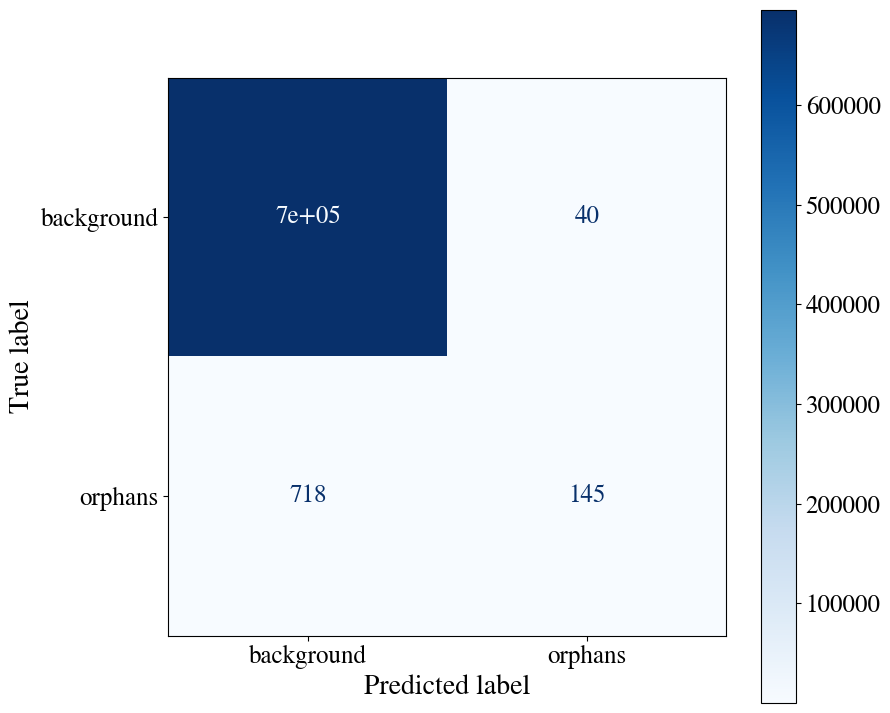

In [39]:
threshold = 0.999
y_pred_bool = np.array(clf.predict_proba(df_norm)[:, 1] >= threshold)
y_test = np.concatenate((np.array(['elasticc']*len(df_el)), np.array(['orphans']*len(df_oa))))

y_pred= []
for y in y_pred_bool:
    if y == True:
        y_pred.append('orphans')
    elif y == False:
        y_pred.append('elasticc')
    else:
        print(y)
        
plt.rcParams["figure.figsize"] = [9, 9]
plt.rcParams["font.size"] = 18

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                              display_labels=['background', 'orphans'],
                                              cmap=plt.cm.Blues)

plt.xlabel('Predicted label', fontsize=20)
plt.ylabel('True label', fontsize=20)

#plt.savefig("/home/masson/afterglowpy/figures/jetsimpy_confu_matrix_model_afterglowpy.pdf", format="pdf", bbox_inches="tight", transparent=True)

## Train the model on the population simulated with `jetsimpy`

In [21]:
##### df_oa['type'] = np.array(['orphans']*len(df_oa))
df_el['type'] = np.array(['elasticc']*len(df_el))
df_el_drop = df_el.drop(columns=['grb_time', 'decrease_rate', 'u-g', 'i-z', 'z-Y', 'alertId'])

In [22]:
df_oa.replace([np.inf, -np.inf], 1000, inplace=True)
df_oa.fillna(0, inplace=True)

df_el_drop.replace([np.inf, -np.inf], 1000, inplace=True)
df_el_drop.fillna(0, inplace=True)

In [23]:
df_oa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 863 entries, 0 to 862
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   duration         863 non-null    float64
 1   increase_rate    863 non-null    float64
 2   decrease_rate_1  863 non-null    float64
 3   decrease_rate_3  863 non-null    float64
 4   g-r              863 non-null    float64
 5   r-i              863 non-null    float64
 6   A                863 non-null    float64
 7   B                863 non-null    float64
 8   C                863 non-null    float64
 9   D                863 non-null    float64
 10  chi2             863 non-null    float64
 11  A/B              863 non-null    float64
 12  type             863 non-null    object 
dtypes: float64(12), object(1)
memory usage: 87.8+ KB


In [24]:
df_el_drop = df_el_drop.sample(frac=1)
df_el_drop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 695359 entries, 150060 to 177396
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   duration         695359 non-null  float64
 1   increase_rate    695359 non-null  float64
 2   decrease_rate_1  695359 non-null  float64
 3   decrease_rate_3  695359 non-null  float64
 4   g-r              695359 non-null  float64
 5   r-i              695359 non-null  float64
 6   A                695359 non-null  float64
 7   B                695359 non-null  float64
 8   C                695359 non-null  float64
 9   D                695359 non-null  float64
 10  A/B              695359 non-null  float64
 11  chi2             695359 non-null  float64
 12  type             695359 non-null  object 
dtypes: float64(12), object(1)
memory usage: 74.3+ MB


In [25]:
df_el_train = df_el_drop[:10000].drop(columns=['type'])
df_el_test = df_el_drop[10000:].drop(columns=['type'])
df_el_train.info()
el_y_train = df_el_drop[:10000]['type']
el_y_test = df_el_drop[10000:]['type']
el_y_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 150060 to 546131
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   duration         10000 non-null  float64
 1   increase_rate    10000 non-null  float64
 2   decrease_rate_1  10000 non-null  float64
 3   decrease_rate_3  10000 non-null  float64
 4   g-r              10000 non-null  float64
 5   r-i              10000 non-null  float64
 6   A                10000 non-null  float64
 7   B                10000 non-null  float64
 8   C                10000 non-null  float64
 9   D                10000 non-null  float64
 10  A/B              10000 non-null  float64
 11  chi2             10000 non-null  float64
dtypes: float64(12)
memory usage: 1015.6 KB
<class 'pandas.core.series.Series'>
Index: 685359 entries, 578287 to 177396
Series name: type
Non-Null Count   Dtype 
--------------   ----- 
685359 non-null  object
dtypes: object(1)
memory usage: 10.5

In [26]:
df_oa_train = df_oa[:400].drop(columns=['type'])
df_oa_test = df_oa[400:].drop(columns=['type'])
df_oa_train.info()
oa_y_train = df_oa[:400]['type']
oa_y_test = df_oa[400:]['type']
oa_y_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   duration         400 non-null    float64
 1   increase_rate    400 non-null    float64
 2   decrease_rate_1  400 non-null    float64
 3   decrease_rate_3  400 non-null    float64
 4   g-r              400 non-null    float64
 5   r-i              400 non-null    float64
 6   A                400 non-null    float64
 7   B                400 non-null    float64
 8   C                400 non-null    float64
 9   D                400 non-null    float64
 10  chi2             400 non-null    float64
 11  A/B              400 non-null    float64
dtypes: float64(12)
memory usage: 37.6 KB
<class 'pandas.core.series.Series'>
RangeIndex: 463 entries, 400 to 862
Series name: type
Non-Null Count  Dtype 
--------------  ----- 
463 non-null    object
dtypes: object(1)
memory usage: 3.7+ KB


In [27]:
X_train = pd.concat([df_el_train, df_oa_train])
X_test = pd.concat([df_el_test, df_oa_test])
y_train = pd.concat([el_y_train, oa_y_train])
y_test = pd.concat([el_y_test, oa_y_test])

In [28]:
X_train_n = preprocessing.normalize(X_train, norm='max')
X_test_n = preprocessing.normalize(X_test, norm='max')

In [29]:
clf_jetsimpy = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                 max_depth=8, random_state=0).fit(X_train_n, y_train)

In [30]:
clf_jetsimpy.score(X_test_n, y_test)

0.9992709478552744

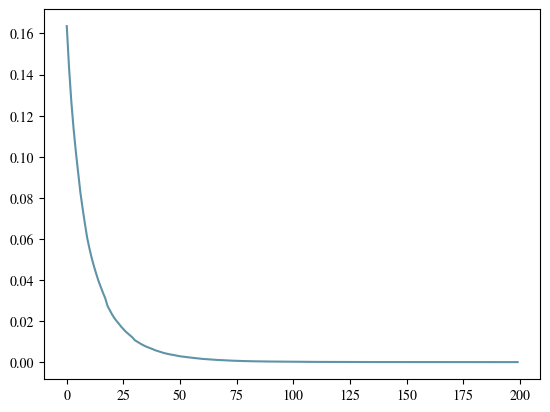

In [31]:
plt.plot(clf_jetsimpy.train_score_, color="#5f93a7")

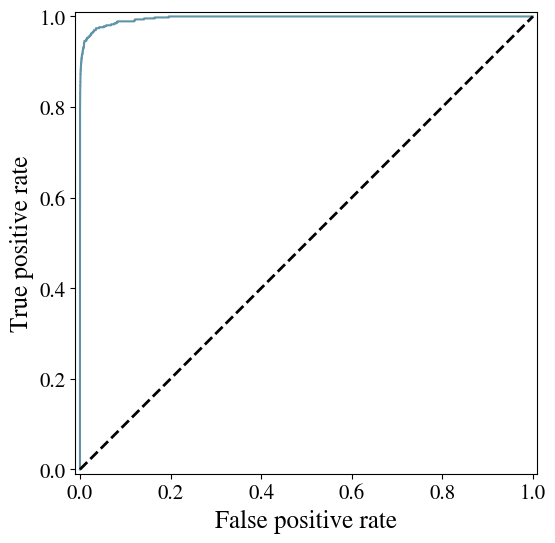

In [32]:
plt.rcParams.update({'font.size': 15})

x = np.linspace(0., 1., 100)
y = np.linspace(0., 1., 100)

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(clf_jetsimpy, X_test_n, y_test, ax=ax, color="#5f93a7")
plt.plot(x, y, color='k', lw=2., ls='--', label='random')
ax.set_xlabel('False positive rate', fontsize=18)
ax.set_ylabel('True positive rate', fontsize=18)
ax.legend_.remove()

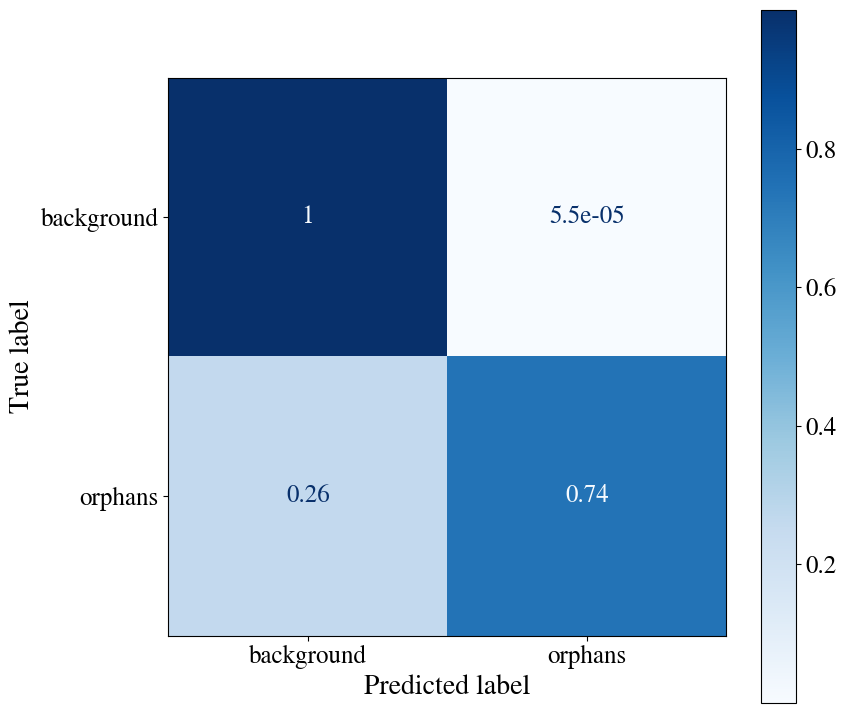

In [43]:
threshold = 0.9999
y_pred_bool = np.array(clf_jetsimpy.predict_proba(X_test_n)[:, 1] >= threshold)

y_pred= []
for y in y_pred_bool:
    if y == True:
        y_pred.append('orphans')
    elif y == False:
        y_pred.append('elasticc')
    else:
        print(y)
        
plt.rcParams["figure.figsize"] = [9, 9]
plt.rcParams["font.size"] = 18

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                              display_labels=['background', 'orphans'],
                                              cmap=plt.cm.Blues,
                                              normalize='true')
plt.xlabel('Predicted label', fontsize=20)
plt.ylabel('True label', fontsize=20)

#plt.savefig("/home/masson/afterglowpy/figures/jetsimpy_confu_matrix.pdf", format="pdf", bbox_inches="tight", transparent=True)

## Optimise hyper parameters using `optuna`

Trying to minimise the number of False Positives (ELAsTiCC labelled as orphans) and maximise the number of True Positives (orphans labelled as orphans).

In [70]:
def objective(trial):
    rf_max_depth = trial.suggest_int("rf_max_depth", 1, 30)
    rf_n_estimators = trial.suggest_int("rf_n_estimators", 100, 250)
    rf_learning_rate = trial.suggest_float("rf_learning_rate", 1e-3, 5e-1, log=True)
    
    clf = GradientBoostingClassifier(n_estimators=rf_n_estimators, learning_rate=rf_learning_rate, max_depth=rf_max_depth, random_state=0)
    clf.fit(X_train_n, y_train)

    proba_orphans = clf.predict_proba(X_test_n)[:, 1]

    true_orphans = proba_orphans[y_test=='orphans']
    true_labelled_orphans = true_orphans[true_orphans >= 0.99]

    false_orphans = proba_orphans[y_test=='elasticc']
    false_labelled_orphans = false_orphans[false_orphans >= 0.99]

    return len(true_labelled_orphans), len(false_labelled_orphans)

sampler = optuna.samplers.TPESampler()
study = optuna.create_study(directions=["maximize", "minimize"], sampler=sampler)
study.optimize(objective, n_trials=100)

[I 2025-02-03 15:39:09,187] A new study created in memory with name: no-name-9f49bd13-9963-4a98-a450-f1144c98665f
[I 2025-02-03 15:39:33,216] Trial 0 finished with values: [373.0, 2025.0] and parameters: {'rf_max_depth': 30, 'rf_n_estimators': 227, 'rf_learning_rate': 0.059787572186055675}.
[I 2025-02-03 15:40:02,739] Trial 1 finished with values: [357.0, 295.0] and parameters: {'rf_max_depth': 9, 'rf_n_estimators': 247, 'rf_learning_rate': 0.03483168591693246}.
[I 2025-02-03 15:40:04,695] Trial 2 finished with values: [140.0, 0.0] and parameters: {'rf_max_depth': 1, 'rf_n_estimators': 111, 'rf_learning_rate': 0.18731518386425133}.
[I 2025-02-03 15:40:27,046] Trial 3 finished with values: [0.0, 0.0] and parameters: {'rf_max_depth': 21, 'rf_n_estimators': 219, 'rf_learning_rate': 0.0030361453291488233}.
[I 2025-02-03 15:40:46,493] Trial 4 finished with values: [0.0, 0.0] and parameters: {'rf_max_depth': 26, 'rf_n_estimators': 183, 'rf_learning_rate': 0.0060458885621285105}.
[I 2025-02-0

In [79]:
print("Number of finished trials: ", len(study.trials))

trials = sorted(study.best_trials, key=lambda t: t.values)

for trial in trials:
    print("Trial  #{}".format(trial.number))
    print("Values: True Orphans={}, False orphans={}".format(trial.values[0], trial.values[1]))
    print("Params: {}".format(trial.params))

Number of finished trials:  100
Trial  #2
Values: True Orphans=140.0, False orphans=0.0
Params: {'rf_max_depth': 1, 'rf_n_estimators': 111, 'rf_learning_rate': 0.18731518386425133}
Trial  #51
Values: True Orphans=237.0, False orphans=4.0
Params: {'rf_max_depth': 5, 'rf_n_estimators': 246, 'rf_learning_rate': 0.024053101369761243}
Trial  #50
Values: True Orphans=242.0, False orphans=8.0
Params: {'rf_max_depth': 5, 'rf_n_estimators': 233, 'rf_learning_rate': 0.025492934639087104}
Trial  #37
Values: True Orphans=320.0, False orphans=14.0
Params: {'rf_max_depth': 5, 'rf_n_estimators': 203, 'rf_learning_rate': 0.060803161694704476}
Trial  #64
Values: True Orphans=349.0, False orphans=18.0
Params: {'rf_max_depth': 5, 'rf_n_estimators': 213, 'rf_learning_rate': 0.09481875039955197}
Trial  #54
Values: True Orphans=351.0, False orphans=21.0
Params: {'rf_max_depth': 6, 'rf_n_estimators': 213, 'rf_learning_rate': 0.0645103726946449}
Trial  #97
Values: True Orphans=352.0, False orphans=51.0
Params

## K-fold cross-validation

>1: mean=0.9997, se=0.000
>2: mean=0.9996, se=0.000
>3: mean=0.9996, se=0.000
>4: mean=0.9996, se=0.000


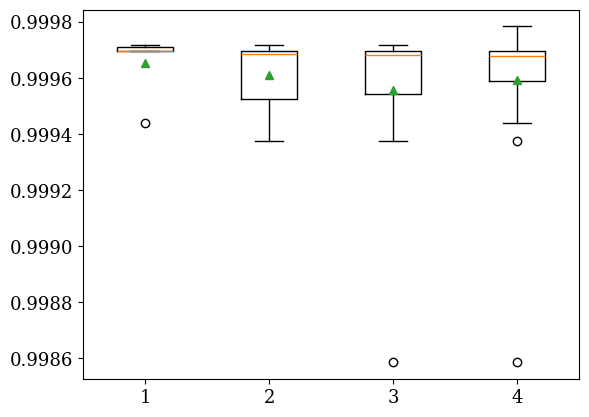

In [114]:
# evaluate a model with a given number of repeats
def evaluate_model(X, y, repeats):
	# prepare the cross-validation procedure
    cv = RepeatedKFold(n_splits=5, n_repeats=repeats, random_state=1)
	# create model
    model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=8, random_state=0)
    # evaluate model
    scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
    return scores

X = pd.concat([df_el, df_oa]).drop(columns=['type'])
y = pd.concat([df_el, df_oa])['type']

# configurations to test
repeats = range(1,5)
results = []
for r in repeats:
    # evaluate using a given number of repeats
    scores = evaluate_model(X, y, r)
    print('>%d: mean=%.4f, se=%.3f' % (r, np.mean(scores), sem(scores)))
    results.append(scores)

plt.boxplot(results, tick_labels=[str(r) for r in repeats], showmeans=True)
plt.ylabel("Accuracy")
plt.show()

## Mixed population `jetsimpy` + `afterglowpy`

In [62]:
df_oa_a = df_oa_el[df_oa_el['type']=='orphans']
df_oa_a_drop = df_oa_a.drop(columns=['grb_time', 'decrease_rate', 'u-g', 'i-z', 'z-Y', 'alertId'])

In [63]:
df_oa_a_drop

,duration,increase_rate,decrease_rate_1,decrease_rate_3,g-r,r-i,A,B,C,D,A/B,chi2,type
0,0.000000,0.000000,0.085273,0.016193,-0.852039,0.113965,0.009522,28.352623,-4.322088,0.028148,0.000336,0.000130,orphans
1,0.000000,0.000000,0.028916,0.010698,0.257427,0.143853,0.020842,23.551006,-1.055726,1.499994,0.000885,0.248048,orphans
2,0.000000,0.000000,0.028003,0.010916,0.122053,0.135443,0.011337,24.121623,-1.562848,0.041076,0.000470,0.004556,orphans
3,4.044343,-0.318760,0.053402,0.012030,0.294058,0.154724,0.032337,23.697549,2.797178,1.386193,0.001365,0.256146,orphans
4,0.000239,0.000000,0.006397,0.004494,0.508994,0.229818,0.005531,25.958781,-0.229910,2.765273,0.000213,0.004923,orphans
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2410,0.023875,0.000000,0.010281,0.006072,0.066319,0.003600,0.008205,26.341999,-1.727452,2.589164,0.000311,0.000909,orphans
2411,0.000000,0.000000,0.030349,0.014150,-0.629707,0.136529,-0.001248,29.754041,-6.369981,0.007064,-0.000042,0.004943,orphans
2412,5.001053,0.000000,0.026619,0.006177,0.476689,0.194135,0.014131,23.378250,-0.005014,2.624155,0.000604,0.618708,orphans
2413,0.000000,0.000000,0.019639,0.007620,0.143818,0.124991,0.018846,23.973286,-1.874974,2.698359,0.000786,0.084269,orphans


In [66]:
df_oa_j = df_oa
df_oa_j['type'] = 'orphans'

In [134]:
df_oa_j

,duration,increase_rate,decrease_rate_1,decrease_rate_3,g-r,r-i,A,B,C,D,chi2,A/B,type
0,0.024818,-0.000071,0.000000,0.000000,0.313041,0.220544,-0.000631,22.711497,0.000000e+00,1.500000,0.000769,-0.000028,orphans
1,22.993968,0.000000,0.004395,0.005313,0.324262,0.225401,0.006726,21.440344,1.893980e-01,9.971463,0.328047,0.000314,orphans
2,0.000000,0.000000,0.044859,0.008399,0.339790,0.221749,0.011037,18.627513,-1.486090e+00,0.071682,19.895499,0.000593,orphans
3,0.000000,0.000000,0.004049,0.003055,0.354543,0.220726,0.005759,23.494464,-9.875024e+06,2.459225,0.002470,0.000245,orphans
4,0.024389,0.000000,0.014704,0.005715,0.086626,0.226944,0.018715,23.924150,-1.923224e+00,0.018961,0.120004,0.000782,orphans
...,...,...,...,...,...,...,...,...,...,...,...,...,...
858,0.024676,0.000000,0.000000,0.000000,NaN,0.355614,0.002832,21.291069,-6.260444e-01,0.174980,0.367418,0.000133,orphans
859,0.000000,-0.000012,0.000143,0.000009,0.323763,0.228790,0.000837,22.034317,5.817080e-01,0.000014,0.040441,0.000038,orphans
860,66.807467,-0.010072,0.000000,0.000000,-0.090246,0.161956,0.001062,22.367079,0.000000e+00,1.500000,0.220699,0.000047,orphans
861,79.882320,-0.057222,0.000218,0.000053,0.166574,0.188840,0.000491,23.848732,0.000000e+00,1.500000,0.102309,0.000021,orphans


In [70]:
df_oa_aj = pd.concat([df_oa_a_drop, df_oa_j])
df_oa_aj

,duration,increase_rate,decrease_rate_1,decrease_rate_3,g-r,r-i,A,B,C,D,A/B,chi2,type
0,0.000000,0.000000,0.085273,0.016193,-0.852039,0.113965,0.009522,28.352623,-4.322088,0.028148,0.000336,0.000130,orphans
1,0.000000,0.000000,0.028916,0.010698,0.257427,0.143853,0.020842,23.551006,-1.055726,1.499994,0.000885,0.248048,orphans
2,0.000000,0.000000,0.028003,0.010916,0.122053,0.135443,0.011337,24.121623,-1.562848,0.041076,0.000470,0.004556,orphans
3,4.044343,-0.318760,0.053402,0.012030,0.294058,0.154724,0.032337,23.697549,2.797178,1.386193,0.001365,0.256146,orphans
4,0.000239,0.000000,0.006397,0.004494,0.508994,0.229818,0.005531,25.958781,-0.229910,2.765273,0.000213,0.004923,orphans
...,...,...,...,...,...,...,...,...,...,...,...,...,...
858,0.024676,0.000000,0.000000,0.000000,NaN,0.355614,0.002832,21.291069,-0.626044,0.174980,0.000133,0.367418,orphans
859,0.000000,-0.000012,0.000143,0.000009,0.323763,0.228790,0.000837,22.034317,0.581708,0.000014,0.000038,0.040441,orphans
860,66.807467,-0.010072,0.000000,0.000000,-0.090246,0.161956,0.001062,22.367079,0.000000,1.500000,0.000047,0.220699,orphans
861,79.882320,-0.057222,0.000218,0.000053,0.166574,0.188840,0.000491,23.848732,0.000000,1.500000,0.000021,0.102309,orphans


In [146]:
df_oa_a_drop.fillna(0, inplace=True)
df_oa_j.fillna(0, inplace=True)

In [71]:
df_oa_aj.replace([np.inf, -np.inf], 1000, inplace=True)
df_oa_aj.fillna(0, inplace=True)

df_el_drop.replace([np.inf, -np.inf], 1000, inplace=True)
df_el_drop.fillna(0, inplace=True)

In [72]:
df_oa_aj = df_oa_aj.sample(frac=1)
df_oa_aj.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3278 entries, 539 to 111
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   duration         3278 non-null   float64
 1   increase_rate    3278 non-null   float64
 2   decrease_rate_1  3278 non-null   float64
 3   decrease_rate_3  3278 non-null   float64
 4   g-r              3278 non-null   float64
 5   r-i              3278 non-null   float64
 6   A                3278 non-null   float64
 7   B                3278 non-null   float64
 8   C                3278 non-null   float64
 9   D                3278 non-null   float64
 10  A/B              3278 non-null   float64
 11  chi2             3278 non-null   float64
 12  type             3278 non-null   object 
dtypes: float64(12), object(1)
memory usage: 358.5+ KB


In [73]:
df_el_drop = df_el_drop.sample(frac=1)
df_el_drop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 695359 entries, 630188 to 53557
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   duration         695359 non-null  float64
 1   increase_rate    695359 non-null  float64
 2   decrease_rate_1  695359 non-null  float64
 3   decrease_rate_3  695359 non-null  float64
 4   g-r              695359 non-null  float64
 5   r-i              695359 non-null  float64
 6   A                695359 non-null  float64
 7   B                695359 non-null  float64
 8   C                695359 non-null  float64
 9   D                695359 non-null  float64
 10  A/B              695359 non-null  float64
 11  chi2             695359 non-null  float64
 12  type             695359 non-null  object 
dtypes: float64(12), object(1)
memory usage: 74.3+ MB


In [74]:
df_el_train = df_el_drop[:10000].drop(columns=['type'])
df_el_test = df_el_drop[10000:].drop(columns=['type'])
df_el_train.info()
el_y_train = df_el_drop[:10000]['type']
el_y_test = df_el_drop[10000:]['type']
el_y_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 630188 to 462311
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   duration         10000 non-null  float64
 1   increase_rate    10000 non-null  float64
 2   decrease_rate_1  10000 non-null  float64
 3   decrease_rate_3  10000 non-null  float64
 4   g-r              10000 non-null  float64
 5   r-i              10000 non-null  float64
 6   A                10000 non-null  float64
 7   B                10000 non-null  float64
 8   C                10000 non-null  float64
 9   D                10000 non-null  float64
 10  A/B              10000 non-null  float64
 11  chi2             10000 non-null  float64
dtypes: float64(12)
memory usage: 1015.6 KB
<class 'pandas.core.series.Series'>
Index: 685359 entries, 47225 to 53557
Series name: type
Non-Null Count   Dtype 
--------------   ----- 
685359 non-null  object
dtypes: object(1)
memory usage: 10.5+ 

In [147]:
df_oa_a_train = df_oa_a_drop[:400].drop(columns=['type'])
df_oa_a_test = df_oa_a_drop[400:].drop(columns=['type'])

df_oa_j_train = df_oa_j[:400].drop(columns=['type'])
df_oa_j_test = df_oa_j[400:].drop(columns=['type'])

df_oa_train = pd.concat([df_oa_a_train, df_oa_j_train])
df_oa_test = pd.concat([df_oa_a_test, df_oa_j_test])

df_oa_train.info()
oa_y_train = df_oa_aj[:800]['type']
oa_y_test = df_oa_aj[800:]['type']
oa_y_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 0 to 399
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   duration         800 non-null    float64
 1   increase_rate    800 non-null    float64
 2   decrease_rate_1  800 non-null    float64
 3   decrease_rate_3  800 non-null    float64
 4   g-r              800 non-null    float64
 5   r-i              800 non-null    float64
 6   A                800 non-null    float64
 7   B                800 non-null    float64
 8   C                800 non-null    float64
 9   D                800 non-null    float64
 10  A/B              800 non-null    float64
 11  chi2             800 non-null    float64
dtypes: float64(12)
memory usage: 81.2 KB
<class 'pandas.core.series.Series'>
Index: 2478 entries, 540 to 111
Series name: type
Non-Null Count  Dtype 
--------------  ----- 
2478 non-null   object
dtypes: object(1)
memory usage: 38.7+ KB


In [148]:
X_train = pd.concat([df_el_train, df_oa_train])
X_test = pd.concat([df_el_test, df_oa_test])
y_train = pd.concat([el_y_train, oa_y_train])
y_test = pd.concat([el_y_test, oa_y_test])

In [149]:
X_train_n = preprocessing.normalize(X_train, norm='max')
X_test_n = preprocessing.normalize(X_test, norm='max')

In [160]:
clf_jetsimpy = GradientBoostingClassifier(n_estimators=160, learning_rate=0.076,
                                 max_depth=6, random_state=0).fit(X_train_n, y_train)

In [161]:
clf_jetsimpy.score(X_test_n, y_test)

0.9986333971565938

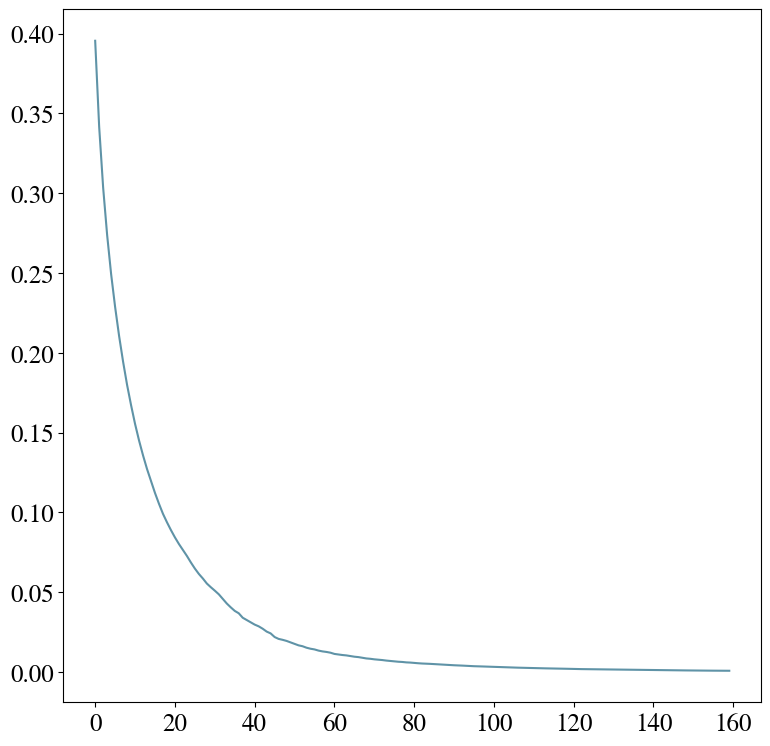

In [162]:
plt.plot(clf_jetsimpy.train_score_, color="#5f93a7")

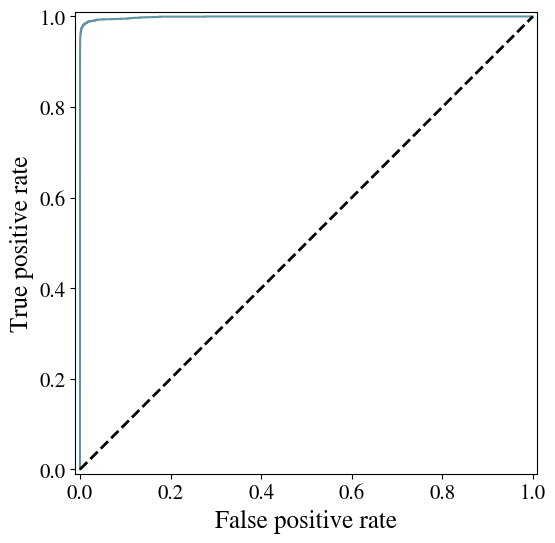

In [163]:
plt.rcParams.update({'font.size': 15})

x = np.linspace(0., 1., 100)
y = np.linspace(0., 1., 100)

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(clf_jetsimpy, X_test_n, y_test, ax=ax, color="#5f93a7")
plt.plot(x, y, color='k', lw=2., ls='--', label='random')
ax.set_xlabel('False positive rate', fontsize=18)
ax.set_ylabel('True positive rate', fontsize=18)
ax.legend_.remove()

Text(0, 0.5, 'True label')

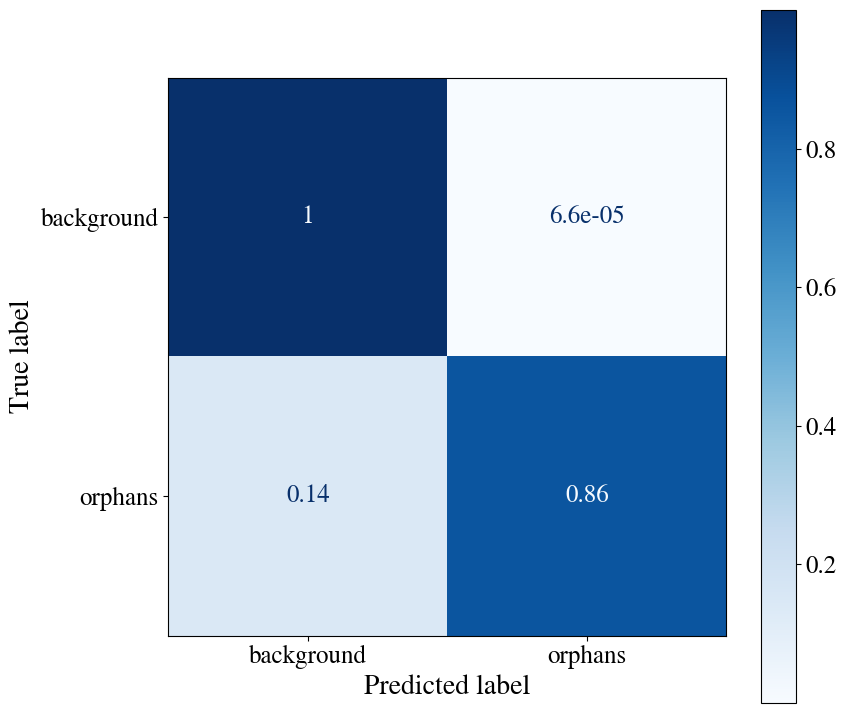

In [168]:
threshold = 0.999
y_pred_bool = np.array(clf_jetsimpy.predict_proba(X_test_n)[:, 1] >= threshold)

y_pred= []
for y in y_pred_bool:
    if y == True:
        y_pred.append('orphans')
    elif y == False:
        y_pred.append('elasticc')
    else:
        print(y)
        
plt.rcParams["figure.figsize"] = [9, 9]
plt.rcParams["font.size"] = 18

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                              display_labels=['background', 'orphans'],
                                              cmap=plt.cm.Blues,
                                              normalize='true')
plt.xlabel('Predicted label', fontsize=20)
plt.ylabel('True label', fontsize=20)

#plt.savefig("/home/masson/afterglowpy/figures/mixed_confu_matrix.pdf", format="pdf", bbox_inches="tight", transparent=True)